In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import pandas as pd
from logic.database import AA_PROPERTIES, AA_CLASS
from extra.onelettercodes import aa_codes
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist

### **Create dataframe with amino acids and their properties**

In [2]:
amino_acids = list(AA_PROPERTIES.keys())

df = pd.DataFrame({
    'volume': [AA_PROPERTIES[aa]['volume'] for aa in amino_acids],
    'hydrophobicity': [AA_PROPERTIES[aa]['hydrophobicity'] for aa in amino_acids],
    'charge': [AA_PROPERTIES[aa]['charge'] for aa in amino_acids],
}, index=amino_acids)

### **Scale values in the dataframe, so that a unit change in each one represents the same thing**

In [3]:

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.values)
df_scaled = pd.DataFrame(X_scaled, index=amino_acids, columns=df.columns)


### **PCA, looking at top 2 components**

In [4]:

pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)  # shape (20, 2)


### **Preliminary dictionaries defining amino acid properties, and color mappings for use later**

In [5]:
AA_VOLUME_CLASS = {
    'G': 'very_small', 'A': 'very_small', 'S': 'very_small',
    'T': 'small', 'C': 'small', 'P': 'small', 'D': 'small', 'N': 'small',
    'V': 'medium', 'H': 'medium', 'E': 'medium', 'Q': 'medium',
    'I': 'large', 'L': 'large', 'M': 'large', 'K': 'large', 'R': 'large',
    'F': 'very_large', 'W': 'very_large', 'Y': 'very_large',
}

VOLUME_COLORS = {
    'very_small': '#264653',
    'small':      '#2a9d8f',
    'medium':     '#e9c46a',
    'large':      '#e76f51',
    'very_large': '#1d3557',
}


CLASS_COLORS = {
    'positive': '#e63946',
    'negative': '#457b9d',
    'polar':    '#2a9d8f',
    'nonpolar': '#e9c46a',
}


### **Plotting of results when PCA was run, with each plot colored for different simulation parameters**

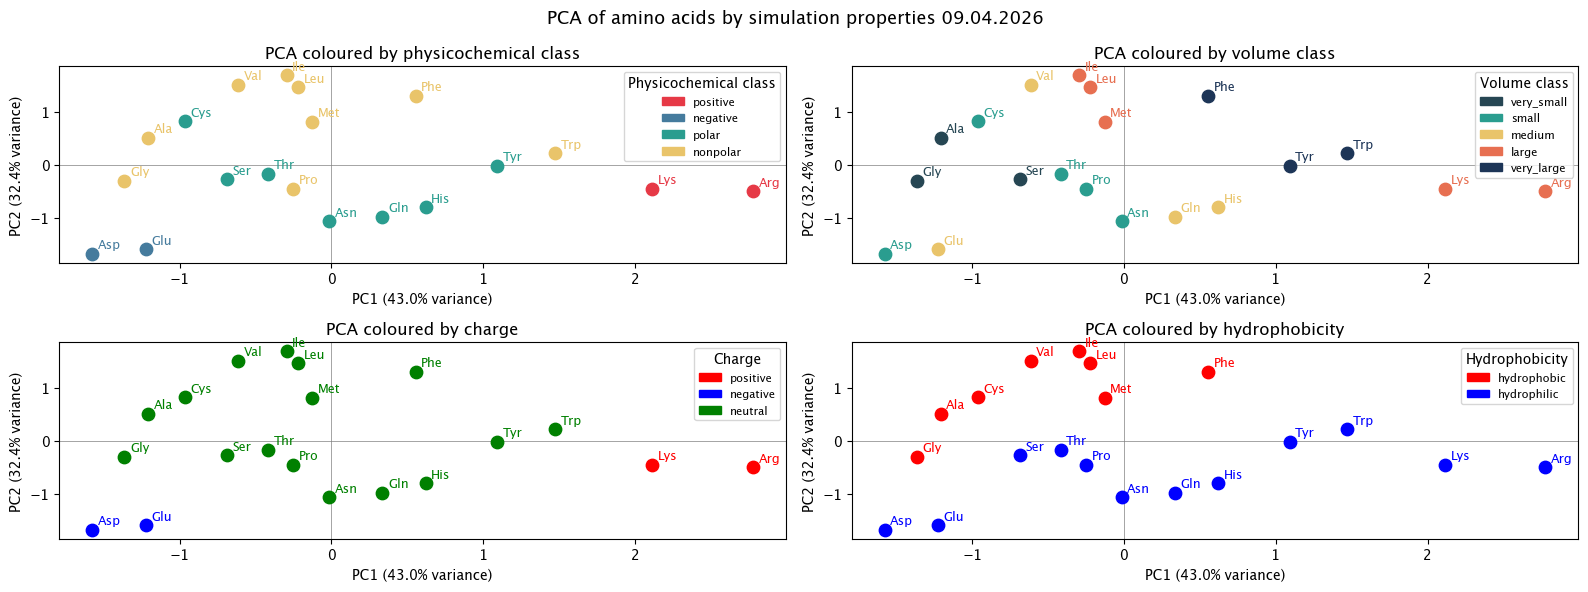

In [6]:


_CHARGE_COLOR = {'positive': 'red', 'negative': 'blue', 'neutral': 'green'}
_charge_map = {aa: 'red' if AA_PROPERTIES[aa]['charge'] > 0 else 'blue' if AA_PROPERTIES[aa]['charge'] < 0 else 'green' for aa in amino_acids}
_charge_legend = {lbl: col for lbl, col in _CHARGE_COLOR.items() if col in _charge_map.values()}

fig, axes = plt.subplots(2, 2, figsize=(16, 6))
axes = axes.flatten()

for ax, color_map, title, label in [
    (axes[0], {aa: CLASS_COLORS[AA_CLASS[aa]]  for aa in amino_acids}, 'Physicochemical class', CLASS_COLORS),
    (axes[1], {aa: VOLUME_COLORS[AA_VOLUME_CLASS[aa]] for aa in amino_acids}, 'Volume class',          VOLUME_COLORS),
    (axes[2], _charge_map, 'Charge', _charge_legend),
    (axes[3], {aa: 'red' if df_scaled.loc[aa, 'hydrophobicity'] > 0 else 'blue' for aa in amino_acids}, 'Hydrophobicity', {'hydrophobic': 'red', 'hydrophilic': 'blue'}),
]:
    for i, aa in enumerate(amino_acids):
        c = color_map[aa]
        ax.scatter(coords[i, 0], coords[i, 1], color=c, s=80, zorder=3)
        ax.annotate(aa_codes[aa], (coords[i, 0], coords[i, 1]), fontsize=9, color=c,
                    xytext=(4, 4), textcoords='offset points')

    handles = [mpatches.Patch(color=col, label=lbl) for lbl, col in label.items()]
    ax.legend(handles=handles, title=title, fontsize=8)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
    ax.set_title(f'PCA coloured by {title.lower()}')
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)

plt.suptitle('PCA of amino acids by simulation properties 09.04.2026', fontsize=13)
plt.tight_layout()
plt.show()



# **4 Clusters Results**


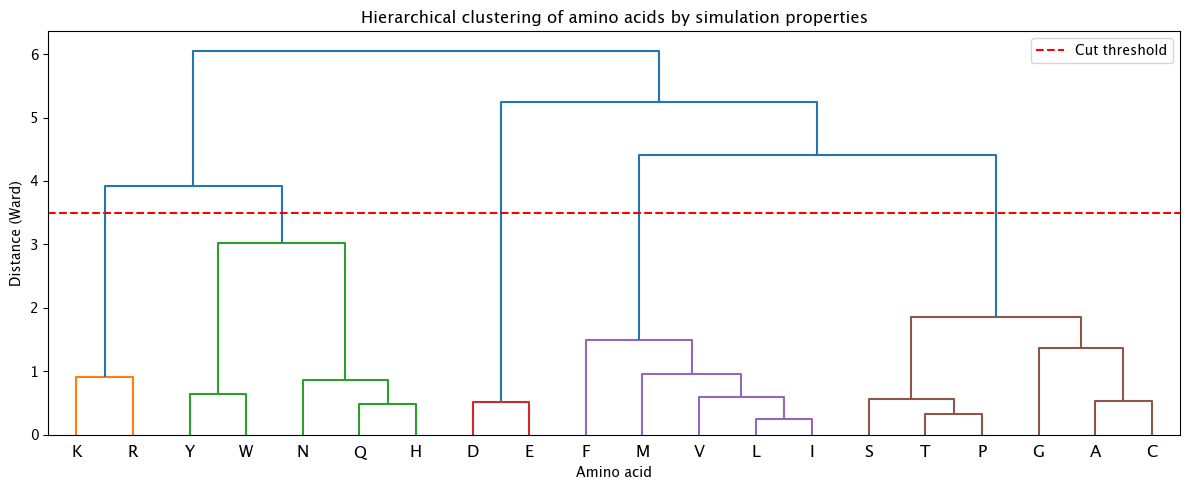

Cluster 1: ['N', 'Q', 'H', 'K', 'R', 'Y', 'W']
Cluster 2: ['D', 'E']
Cluster 3: ['V', 'L', 'I', 'M', 'F']
Cluster 4: ['G', 'A', 'S', 'T', 'C', 'P']


In [9]:
# 'ward' minimizes variance within clusters — good default
linkage_matrix = linkage(X_scaled, method='ward')

# --- 4. Plot dendrogram ---
fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(
    linkage_matrix,
    labels=amino_acids,
    ax=ax,
    color_threshold=3.5  # adjust this to change where clusters are cut
)
ax.set_title('Hierarchical clustering of amino acids by simulation properties')
ax.set_xlabel('Amino acid')
ax.set_ylabel('Distance (Ward)')
ax.axhline(y=3.5, color='red', linestyle='--', label='Cut threshold')
ax.legend()
plt.tight_layout()
plt.show()

# --- 5. Extract flat clusters ---
n_clusters = 4  # start with 4 to compare against your physicochemical scheme
labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')

cluster_df = pd.DataFrame({'AA': amino_acids, 'cluster': labels})
for c in sorted(cluster_df['cluster'].unique()):
    members = cluster_df[cluster_df['cluster'] == c]['AA'].tolist()
    print(f"Cluster {c}: {members}")

In [15]:
for c in sorted(cluster_df['cluster'].unique()):
    members = cluster_df[cluster_df['cluster'] == c]['AA'].tolist()
    print(f"Cluster {c}: {members}")
    for aa in members:
        print(f"{aa}: class={AA_CLASS[aa]}, volume_class={AA_VOLUME_CLASS[aa]}")
    print(f"Cluster {c} classes: {[AA_CLASS[aa] for aa in members]}")
    print(f"Cluster {c} volume classes: {[AA_VOLUME_CLASS[aa] for aa in members]}")
    print("----------------------------------------------------------------")


Cluster 1: ['N', 'Q', 'H', 'K', 'R', 'Y', 'W']
N: class=polar, volume_class=small
Q: class=polar, volume_class=medium
H: class=polar, volume_class=medium
K: class=positive, volume_class=large
R: class=positive, volume_class=large
Y: class=polar, volume_class=very_large
W: class=nonpolar, volume_class=very_large
Cluster 1 classes: ['polar', 'polar', 'polar', 'positive', 'positive', 'polar', 'nonpolar']
Cluster 1 volume classes: ['small', 'medium', 'medium', 'large', 'large', 'very_large', 'very_large']
----------------------------------------------------------------
Cluster 2: ['D', 'E']
D: class=negative, volume_class=small
E: class=negative, volume_class=medium
Cluster 2 classes: ['negative', 'negative']
Cluster 2 volume classes: ['small', 'medium']
----------------------------------------------------------------
Cluster 3: ['V', 'L', 'I', 'M', 'F']
V: class=nonpolar, volume_class=medium
L: class=nonpolar, volume_class=large
I: class=nonpolar, volume_class=large
M: class=nonpolar, vol

# More cluster Experimentation

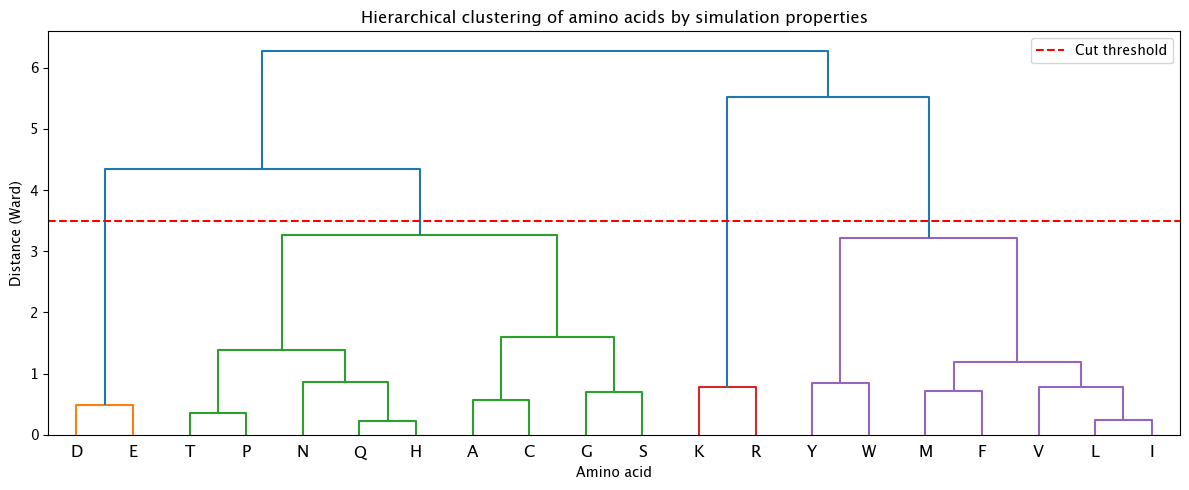

Cluster 1: ['D', 'E']
Cluster 2: ['T', 'N', 'Q', 'P', 'H']
Cluster 3: ['G', 'A', 'S', 'C']
Cluster 4: ['K', 'R']
Cluster 5: ['V', 'L', 'I', 'M', 'F', 'Y', 'W']


In [10]:
# 'ward' minimizes variance within clusters — good default
linkage_matrix = linkage(X_scaled, method='ward')

# --- 4. Plot dendrogram ---
fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(
    linkage_matrix,
    labels=amino_acids,
    ax=ax,
    color_threshold=3.5  # adjust this to change where clusters are cut
)
ax.set_title('Hierarchical clustering of amino acids by simulation properties')
ax.set_xlabel('Amino acid')
ax.set_ylabel('Distance (Ward)')
ax.axhline(y=3.5, color='red', linestyle='--', label='Cut threshold')
ax.legend()
plt.tight_layout()
plt.show()

# --- 5. Extract flat clusters ---
n_clusters = 5  # start with 4 to compare against your physicochemical scheme
labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')

cluster_df = pd.DataFrame({'AA': amino_acids, 'cluster': labels})
for c in sorted(cluster_df['cluster'].unique()):
    members = cluster_df[cluster_df['cluster'] == c]['AA'].tolist()
    print(f"Cluster {c}: {members}")

In [11]:
for c in sorted(cluster_df['cluster'].unique()):
    members = cluster_df[cluster_df['cluster'] == c]['AA'].tolist()
    print(f"Cluster {c}: {members}")
    for aa in members:
        print(f"{aa}: class={AA_CLASS[aa]}, volume_class={AA_VOLUME_CLASS[aa]}")
    print(f"Cluster {c} classes: {[AA_CLASS[aa] for aa in members]}")
    print(f"Cluster {c} volume classes: {[AA_VOLUME_CLASS[aa] for aa in members]}")
    print("----------------------------------------------------------------")


Cluster 1: ['D', 'E']
D: class=negative, volume_class=small
E: class=negative, volume_class=medium
Cluster 1 classes: ['negative', 'negative']
Cluster 1 volume classes: ['small', 'medium']
----------------------------------------------------------------
Cluster 2: ['T', 'N', 'Q', 'P', 'H']
T: class=polar, volume_class=small
N: class=polar, volume_class=small
Q: class=polar, volume_class=medium
P: class=nonpolar, volume_class=small
H: class=polar, volume_class=medium
Cluster 2 classes: ['polar', 'polar', 'polar', 'nonpolar', 'polar']
Cluster 2 volume classes: ['small', 'small', 'medium', 'small', 'medium']
----------------------------------------------------------------
Cluster 3: ['G', 'A', 'S', 'C']
G: class=nonpolar, volume_class=very_small
A: class=nonpolar, volume_class=very_small
S: class=polar, volume_class=very_small
C: class=polar, volume_class=small
Cluster 3 classes: ['nonpolar', 'nonpolar', 'polar', 'polar']
Cluster 3 volume classes: ['very_small', 'very_small', 'very_small'

In [ ]:
CLUSTER_5_COLORS = {
    '1, negative': 'blue',
    '2, polar and small': 'orange',
    '3, small': 'green',
    '4, positive': 'red',
    '5, large and nonpolar(with one polar)': 'purple'
}

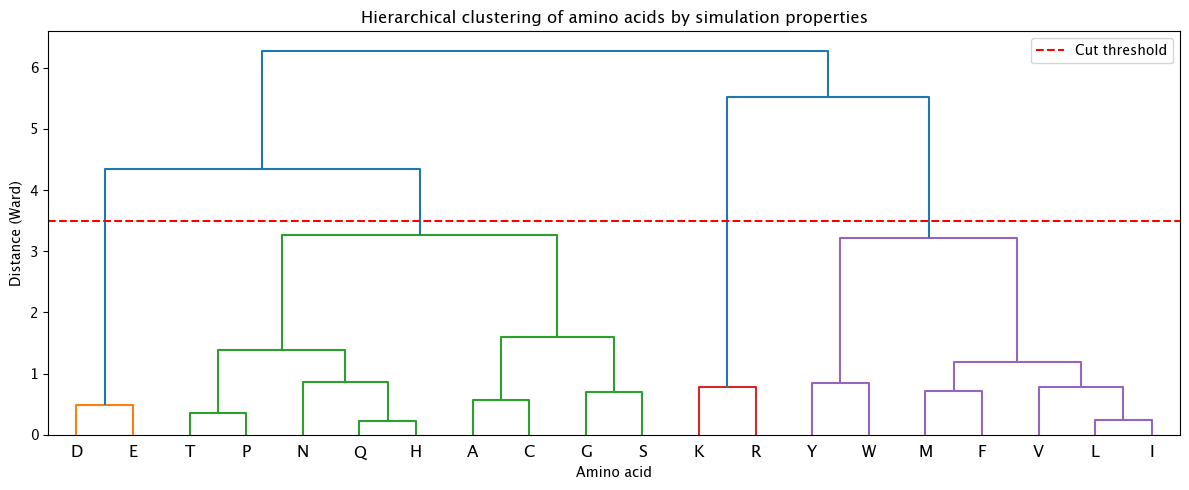

Cluster 1: ['D', 'E']
Cluster 2: ['T', 'N', 'Q', 'P', 'H']
Cluster 3: ['G', 'A', 'S', 'C']
Cluster 4: ['K', 'R']
Cluster 5: ['Y', 'W']
Cluster 6: ['V', 'L', 'I', 'M', 'F']


In [13]:
# 'ward' minimizes variance within clusters — good default
linkage_matrix = linkage(X_scaled, method='ward')

# --- 4. Plot dendrogram ---
fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(
    linkage_matrix,
    labels=amino_acids,
    ax=ax,
    color_threshold=3.5  # adjust this to change where clusters are cut
)
ax.set_title('Hierarchical clustering of amino acids by simulation properties')
ax.set_xlabel('Amino acid')
ax.set_ylabel('Distance (Ward)')
ax.axhline(y=3.5, color='red', linestyle='--', label='Cut threshold')
ax.legend()
plt.tight_layout()
plt.show()

# --- 5. Extract flat clusters ---
n_clusters = 6  # start with 4 to compare against your physicochemical scheme
labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')

cluster_df = pd.DataFrame({'AA': amino_acids, 'cluster': labels})
for c in sorted(cluster_df['cluster'].unique()):
    members = cluster_df[cluster_df['cluster'] == c]['AA'].tolist()
    print(f"Cluster {c}: {members}")

In [14]:
for c in sorted(cluster_df['cluster'].unique()):
    members = cluster_df[cluster_df['cluster'] == c]['AA'].tolist()
    print(f"Cluster {c}: {members}")
    for aa in members:
        print(f"{aa}: class={AA_CLASS[aa]}, volume_class={AA_VOLUME_CLASS[aa]}")
    print(f"Cluster {c} classes: {[AA_CLASS[aa] for aa in members]}")
    print(f"Cluster {c} volume classes: {[AA_VOLUME_CLASS[aa] for aa in members]}")
    print("----------------------------------------------------------------")


Cluster 1: ['D', 'E']
D: class=negative, volume_class=small
E: class=negative, volume_class=medium
Cluster 1 classes: ['negative', 'negative']
Cluster 1 volume classes: ['small', 'medium']
----------------------------------------------------------------
Cluster 2: ['T', 'N', 'Q', 'P', 'H']
T: class=polar, volume_class=small
N: class=polar, volume_class=small
Q: class=polar, volume_class=medium
P: class=nonpolar, volume_class=small
H: class=polar, volume_class=medium
Cluster 2 classes: ['polar', 'polar', 'polar', 'nonpolar', 'polar']
Cluster 2 volume classes: ['small', 'small', 'medium', 'small', 'medium']
----------------------------------------------------------------
Cluster 3: ['G', 'A', 'S', 'C']
G: class=nonpolar, volume_class=very_small
A: class=nonpolar, volume_class=very_small
S: class=polar, volume_class=very_small
C: class=polar, volume_class=small
Cluster 3 classes: ['nonpolar', 'nonpolar', 'polar', 'polar']
Cluster 3 volume classes: ['very_small', 'very_small', 'very_small'

In [ ]:
CLUSTER_6_COLORS = {
    '1, negative': 'blue',
    '2, polar and small(one NP)': 'orange',
    '3, verysmall-small': 'green',
    '4, positive': 'red',
    '5, very large': 'purple',
    '6, nonpolar': 'brown'
}

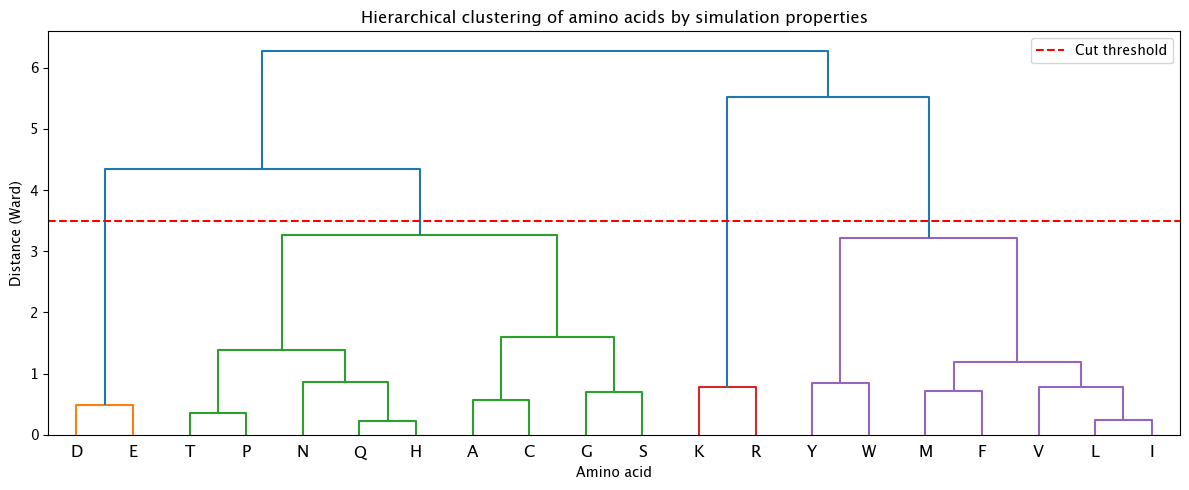

Cluster 1: ['D', 'E']
Cluster 2: ['T', 'N', 'Q', 'P', 'H']
Cluster 3: ['A', 'C']
Cluster 4: ['G', 'S']
Cluster 5: ['K', 'R']
Cluster 6: ['Y', 'W']
Cluster 7: ['V', 'L', 'I', 'M', 'F']


In [15]:
# 'ward' minimizes variance within clusters — good default
linkage_matrix = linkage(X_scaled, method='ward')

# --- 4. Plot dendrogram ---
fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(
    linkage_matrix,
    labels=amino_acids,
    ax=ax,
    color_threshold=3.5  # adjust this to change where clusters are cut
)
ax.set_title('Hierarchical clustering of amino acids by simulation properties')
ax.set_xlabel('Amino acid')
ax.set_ylabel('Distance (Ward)')
ax.axhline(y=3.5, color='red', linestyle='--', label='Cut threshold')
ax.legend()
plt.tight_layout()
plt.show()

# --- 5. Extract flat clusters ---
n_clusters = 7  # start with 4 to compare against your physicochemical scheme
labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')

cluster_df = pd.DataFrame({'AA': amino_acids, 'cluster': labels})
for c in sorted(cluster_df['cluster'].unique()):
    members = cluster_df[cluster_df['cluster'] == c]['AA'].tolist()
    print(f"Cluster {c}: {members}")

In [16]:
for c in sorted(cluster_df['cluster'].unique()):
    members = cluster_df[cluster_df['cluster'] == c]['AA'].tolist()
    print(f"Cluster {c}: {members}")
    for aa in members:
        print(f"{aa}: class={AA_CLASS[aa]}, volume_class={AA_VOLUME_CLASS[aa]}")
    print(f"Cluster {c} classes: {[AA_CLASS[aa] for aa in members]}")
    print(f"Cluster {c} volume classes: {[AA_VOLUME_CLASS[aa] for aa in members]}")
    print("----------------------------------------------------------------")


Cluster 1: ['D', 'E']
D: class=negative, volume_class=small
E: class=negative, volume_class=medium
Cluster 1 classes: ['negative', 'negative']
Cluster 1 volume classes: ['small', 'medium']
----------------------------------------------------------------
Cluster 2: ['T', 'N', 'Q', 'P', 'H']
T: class=polar, volume_class=small
N: class=polar, volume_class=small
Q: class=polar, volume_class=medium
P: class=nonpolar, volume_class=small
H: class=polar, volume_class=medium
Cluster 2 classes: ['polar', 'polar', 'polar', 'nonpolar', 'polar']
Cluster 2 volume classes: ['small', 'small', 'medium', 'small', 'medium']
----------------------------------------------------------------
Cluster 3: ['A', 'C']
A: class=nonpolar, volume_class=very_small
C: class=polar, volume_class=small
Cluster 3 classes: ['nonpolar', 'polar']
Cluster 3 volume classes: ['very_small', 'small']
----------------------------------------------------------------
Cluster 4: ['G', 'S']
G: class=nonpolar, volume_class=very_small
S

In [ ]:
CLUSTER_7_COLORS = {
    '1, negative': 'blue',
    '2, polar and small(one NP)': 'orange',
    '3, verysmall-small': 'green',
    '4, very small': 'red',
    '5, positive': 'purple',
    '6, very large': 'brown',
    '7, nonpolar': 'cyan'
}